# 03 – Geology and surface analysis of Heard Island

Prepares the input layers for the geology analysis:

1. **Study area** – read the bounding box exported from QGIS and build a common 25 m grid
2. **Input data** – geology map and 10 m DEM from the Australian Antarctic Data Centre
3. **Terrain derivatives** – slope, aspect and hillshade from the DEM
4. **Helpers** – raster reclassification and reproject/clip tools
5. **Apply** – clip and reproject layers onto the project grid (following on from earlier steps with EPSG:32743)

Setup

In [2]:
import os
import sys
import uuid
import zipfile
from pathlib import Path

# ---- Environment: point PROJ/GDAL at the active conda env (set before importing geo libraries) ----
CONDA_PREFIX = sys.prefix
os.environ["PROJ_LIB"] = os.path.join(CONDA_PREFIX, "share", "proj")
os.environ["GDAL_DATA"] = os.path.join(CONDA_PREFIX, "share", "gdal")

# ---- Start QGIS (needed for processing.run) ----
from qgis.core import QgsApplication, QgsCoordinateReferenceSystem, QgsVectorLayer

if not QgsApplication.instance():
    QgsApplication.setPrefixPath(CONDA_PREFIX, True)
    qgs = QgsApplication([], False)
    qgs.initQgis()
    print("QGIS initialised")
else:
    print("QGIS is already ready")
    
import processing
from processing.core.Processing import Processing
from qgis.analysis import QgsNativeAlgorithms

# Register the Processing providers (GDAL, etc.) and the native algorithms in this standalone session
Processing.initialize()
if QgsApplication.processingRegistry().providerById("native") is None:
    QgsApplication.processingRegistry().addProvider(QgsNativeAlgorithms())

# Sanity check: these are the algorithms the notebook uses
for alg_id in ("gdal:warpreproject", "gdal:slope", "native:clip", "native:reprojectlayer", "native:reclassifybytable"):
    found = QgsApplication.processingRegistry().algorithmById(alg_id) is not None
    print(f"{alg_id}: {'OK' if found else 'NOT FOUND'}")

# ---- Geo libraries ----
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import shapely
from shapely.geometry import box
from osgeo import gdal

gdal.UseExceptions()

# ---- Project configuration: edit these, not the code below ----
def find_repo_root(start=None):
    """Walk up from the notebook's folder until a .git folder is found."""
    start = Path(start or Path.cwd()).resolve()
    for folder in (start, *start.parents):
        if (folder / ".git").exists():
            return folder
    raise FileNotFoundError("No .git folder found above " + str(start))

REPO_ROOT  = find_repo_root()
inpath     = REPO_ROOT / "Input_Data"
outpath    = REPO_ROOT / "Output_Data"
TEMP_DIR   = outpath / "temp"            # scratch space for intermediate vectors
TARGET_CRS = "EPSG:32743"                 # EPSG:32743
CELL_SIZE  = 25                          # metres; every raster shares this grid

# Study area (area of interest) in WGS84 lon/lat: [xmin, ymin, xmax, ymax]
aoi_wgs84 = [73.45, -53.25, 73.85, -52.95]

GEOLOGY_ZIP = inpath / "Geology" / "Heard_Island_Geology_Map.zip"

for d in (outpath, TEMP_DIR):
    d.mkdir(parents=True, exist_ok=True)

QGIS is already ready
gdal:warpreproject: OK
gdal:slope: OK
native:clip: OK
native:reprojectlayer: OK
native:reclassifybytable: OK


Unzipper for downloaded zipped datasets and deal with shapefiles with unclosed polygons.

In [3]:
def extract_if_zip(local_file, output_dir):
    """Unzip `local_file` into <output_dir>/extracted and return that folder.
    If it isn't a zip, return the folder it already lives in."""
    os.makedirs(output_dir, exist_ok=True)
    if zipfile.is_zipfile(local_file):
        extract_to = os.path.join(output_dir, "extracted")
        with zipfile.ZipFile(local_file) as z:
            z.extractall(extract_to)
        return extract_to
    return os.path.dirname(local_file)


def read_vector_safe(path):
    """Read a vector file with geopandas.

    Some shapefiles (e.g. the Heard Island geology) contain polygon rings whose first and last
    points differ, which shapely rejects with:
        GEOSException: Points of LinearRing do not form a closed linestring
    If that happens, re-read with on_invalid="fix" (needs shapely >= 2.1), which closes the rings.
    """
    try:
        return gpd.read_file(path)
    except shapely.errors.GEOSException as e:
        print(f"geopandas could not read {os.path.basename(path)} ({e}); re-reading with on_invalid='fix'")
        try:
            gdf = gpd.read_file(path, on_invalid="fix")
        except ValueError:
            raise RuntimeError(
                f"This shapefile needs shapely >= 2.1 to repair (installed: {shapely.__version__}). "
                "Run: conda install -c conda-forge 'shapely>=2.1' pyogrio geopandas, then restart the kernel."
            ) from e

        n_missing = int(gdf.geometry.isna().sum())
        if n_missing:
            print(f"WARNING: {n_missing} geometries could not be repaired and are empty (None)")
        invalid = gdf.geometry.notna() & ~gdf.geometry.is_valid
        if invalid.any():
            print(f"Repairing {int(invalid.sum())} remaining invalid geometries with make_valid()")
            gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].make_valid()
        return gdf

Study area and project grid
The AOI is defined by `aoi_wgs84` (lon/lat) in the setup cell. It is reprojected to the project CRS and
snapped to the cell size so every raster ends up with identical row/column counts.

In [4]:
# Build the study area polygon from the AOI coordinates (WGS84 lon/lat)
study_area = gpd.GeoDataFrame(geometry=[box(*aoi_wgs84)], crs="EPSG:4326")

# STAC bounding boxes need to be WGS84 lon/lat: [xmin, ymin, xmax, ymax]
bbox = list(aoi_wgs84)

# Project CRS version of the study area, saved so PyQGIS can use it as a clip layer
study_area_proj = study_area.to_crs(TARGET_CRS)
aoi_path = outpath / "aoi_projected.gpkg"
study_area_proj.to_file(aoi_path, driver="GPKG")
bounding_vector = QgsVectorLayer(str(aoi_path), "AOI")   # for PyQGIS clip tools

xmin, ymin, xmax, ymax = study_area_proj.total_bounds

# Snap the extent outward to the cell size
xmin = xmin - (xmin % CELL_SIZE)
ymin = ymin - (ymin % CELL_SIZE)
xmax = xmin + CELL_SIZE * (((xmax - xmin) // CELL_SIZE) + 1)
ymax = ymin + CELL_SIZE * (((ymax - ymin) // CELL_SIZE) + 1)

cols = int(round((xmax - xmin) / CELL_SIZE))
rows = int(round((ymax - ymin) / CELL_SIZE))

# String format QGIS Processing expects for EXTENT parameters: "xmin,xmax,ymin,ymax [EPSG:code]"
global_extent_str = f"{xmin},{xmax},{ymin},{ymax} [{TARGET_CRS}]"

print(global_extent_str, cols, rows)

395850.0,423275.0,4098775.0,4132675.0 [EPSG:32743] 1097 1356


Input data.
First geology map from the Australian Antarctic Data Cetre

In [5]:
GEOLOGY_DIR = "heard_island_geology"
search_dir = extract_if_zip(GEOLOGY_ZIP, GEOLOGY_DIR)

# Find whatever spatial files are in the archive
shapefiles, gdbs = [], []
for root, dirs, files in os.walk(search_dir):
    gdbs += [os.path.join(root, d) for d in dirs if d.lower().endswith(".gdb")]
    shapefiles += [os.path.join(root, f) for f in files if f.lower().endswith(".shp")]

print("Shapefiles found:", shapefiles)
print("Geodatabases found:", gdbs)

# The archive holds several shapefiles (contours, outline, dates...), so pick the geology polygons by name
geology_shp = next((s for s in shapefiles if "geology" in os.path.basename(s).lower()), None)

if geology_shp:
    gdf = read_vector_safe(geology_shp)
    print("Using:", geology_shp)
    print(gdf.head())
    print(f"CRS: {gdf.crs}")
elif gdbs:
    import fiona
    layers = fiona.listlayers(gdbs[0])
    print("Layers in geodatabase:", layers)
    gdf = gpd.read_file(gdbs[0], layer=layers[0])
    print(gdf.head())

Shapefiles found: ['heard_island_geology/extracted/Big Ben Lines.shp', 'heard_island_geology/extracted/Ar_dates.shp', 'heard_island_geology/extracted/HI_Geology_poly.shp', 'heard_island_geology/extracted/hi_contours.shp', 'heard_island_geology/extracted/HI_Outline.shp', 'heard_island_geology/extracted/contours_20m.shp', 'heard_island_geology/extracted/contours_20m_2.shp']
Geodatabases found: ['heard_island_geology/extracted/AADC_Fox_Heard.gdb']
geopandas could not read HI_Geology_poly.shp (IllegalArgumentException: Points of LinearRing do not form a closed linestring); re-reading with on_invalid='fix'
Using: heard_island_geology/extracted/HI_Geology_poly.shp
   Id Rock_Type       Area                                           geometry
0   0  Snow/Ice  3822504.0  POLYGON ((387431.247 4127814.136, 387414.578 4...
1   0  Snow/Ice    21406.0  POLYGON ((387613.016 4125510.669, 387616.191 4...
2   0  Snow/Ice     1068.0  POLYGON ((387598.464 4125647.988, 387599.522 4...
3   0  Snow/Ice  1347

/Users/jamessampson/miniconda3/envs/KGG375_AT2/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(
/Users/jamessampson/miniconda3/envs/KGG375_AT2/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(
/Users/jamessampson/miniconda3/envs/KGG375_AT2/lib/python3.12/site-packages/shapely/io.py:353: RuntimeWarning: invalid value encountered in from_wkb
  return lib.from_wkb(geometry, invalid_handler, **kwargs)


Reclassify rasters

In [6]:
def reclassify_raster(input_raster, output_raster, classification_table, range_boundaries):
    """
    Reclassify a raster using a classification table (native:reclassifybytable).

    Example classification table (min, max, new value):
        table = [
            0.0, 0.2, 1,        # Very low
            0.2, 0.4, 2,        # Low
            0.4, 0.6, 3,        # Moderate
            0.6, 0.8, 4,        # High
            0.8, 1.000001, 5,   # Very high
        ]
    """
    result = processing.run("native:reclassifybytable", {
        'INPUT_RASTER': str(input_raster),
        'RASTER_BAND': 1,            # keep this constant
        'TABLE': classification_table,
        'NO_DATA': -9999,
        'RANGE_BOUNDARIES': range_boundaries,
        'NODATA_FOR_MISSING': False,
        'OUTPUT': str(output_raster),
    })
    return result["OUTPUT"]

Project and clip layers to study area

In [7]:
GRID = {
    "extent_str": global_extent_str,
    "cols": cols,
    "rows": rows,
    "crs": QgsCoordinateReferenceSystem(TARGET_CRS),
}
print(GRID)


def snap_to_grid(input_path, output_path, grid, resampling_method=0):
    """Force any raster onto the project's pixel grid, regardless of how it was created."""
    result = processing.run("gdal:warpreproject", {
        'INPUT': str(input_path),
        'TARGET_CRS': grid["crs"],
        'RESAMPLING': resampling_method,
        'TARGET_EXTENT': grid["extent_str"],
        'TARGET_EXTENT_CRS': grid["crs"],
        'EXTRA': f'-ts {grid["cols"]} {grid["rows"]}',
        'OUTPUT': str(output_path),
    })
    return result['OUTPUT']


def project_and_clip(input_layer, output_path, bounding_box, layer_type="raster",
                     resampling_method=None, cell_size=CELL_SIZE, target_crs=TARGET_CRS, grid=None):
    """
    Reproject and clip a layer to the project's consistent geometry and projection.

    raster: reproject to `target_crs` at `cell_size`, then snap onto `grid`.
    vector: clip to `bounding_box`, then reproject to `target_crs`.
    """
    target_crs = QgsCoordinateReferenceSystem(target_crs)
    output_path = str(output_path)

    if layer_type == "raster":
        reproject_result = processing.run("gdal:warpreproject", {
            'INPUT': input_layer,
            'TARGET_CRS': target_crs,
            'RESAMPLING': resampling_method,
            'TARGET_RESOLUTION': cell_size,
            'OUTPUT': 'TEMPORARY_OUTPUT',
        })
        return snap_to_grid(reproject_result['OUTPUT'], output_path, grid, resampling_method)

    elif layer_type == "vector":
        temp_clip_path = str(TEMP_DIR / f"clip_{uuid.uuid4().hex}.gpkg")

        try:
            clip_result = processing.run("native:clip", {
                'INPUT': input_layer,
                'OVERLAY': bounding_box,
                'OUTPUT': temp_clip_path,
            })
        except Exception as e:
            print(f"CLIP FAILED for {output_path}: {e}")
            raise

        try:
            reproject_result = processing.run("native:reprojectlayer", {
                'INPUT': clip_result['OUTPUT'],
                'TARGET_CRS': target_crs,
                'OUTPUT': output_path,
            })
        except Exception as e:
            print(f"REPROJECT FAILED for {output_path}: {e}")
            raise

        return reproject_result['OUTPUT']

    else:
        raise ValueError("layer_type must be 'raster' or 'vector'")

{'extent_str': '395850.0,423275.0,4098775.0,4132675.0 [EPSG:32743]', 'cols': 1097, 'rows': 1356, 'crs': <QgsCoordinateReferenceSystem: EPSG:32743>}


Visualise the geology layers
Clip the geology polygons (`gdf`, read from `HI_Geology_poly.shp` above) to the study area, then map each rock type and summarise how much of the study area each one covers.

In [ ]:
# ---- Prepare geology for plotting ----
import ipywidgets as widgets
from IPython.display import display, clear_output

geo = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()   # drop the geometries that could not be repaired
geo = geo.to_crs(TARGET_CRS)
geo = gpd.clip(geo, study_area_proj)                               # keep only the study area
geo["Rock_Type"] = geo["Rock_Type"].fillna("Unknown")

# One colour per rock type (snow/ice and water get natural colours, everything else comes from tab20)
rock_types = sorted(geo["Rock_Type"].unique())
palette = plt.get_cmap("tab20")
colours = {}
for i, rt in enumerate(rock_types):
    name = rt.lower()
    if "snow" in name or "ice" in name or "glac" in name:
        colours[rt] = "#d6ecf7"
    elif "water" in name or "lake" in name:
        colours[rt] = "#4a90c2"
    else:
        colours[rt] = palette(i % 20)

# ---- Map ----
fig, ax = plt.subplots(figsize=(10, 9))

# Optional hillshade-style backdrop from the clipped DEM, if it has been created
dem_file = outpath / "DEM_25m_7855_clipped.tif"
if dem_file.exists():
    from matplotlib.colors import LightSource
    with rasterio.open(dem_file) as src:
        dem = src.read(1, masked=True)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    hs = LightSource(azdeg=315, altdeg=45).hillshade(dem.filled(dem.min()), vert_exag=2, dx=CELL_SIZE, dy=CELL_SIZE)
    ax.imshow(hs, extent=extent, cmap="gray", alpha=0.6, zorder=0)

for rt in rock_types:
    sub = geo[geo["Rock_Type"] == rt]
    sub.plot(ax=ax, color=colours[rt], edgecolor="black", linewidth=0.3, alpha=0.75, zorder=1)

study_area_proj.boundary.plot(ax=ax, color="red", linewidth=1.2, linestyle="--", zorder=2)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colours[rt], edgecolor="black", linewidth=0.5) for rt in rock_types]
ax.legend(handles, rock_types, title="Rock type", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
ax.set_title("Heard Island geology")
ax.set_xlabel(f"Easting (m, {TARGET_CRS})")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
ax.ticklabel_format(style="plain")

# Start zoomed to the study area
x0, y0, x1, y1 = study_area_proj.total_bounds
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
home_xlim, home_ylim = ax.get_xlim(), ax.get_ylim()

plt.tight_layout()
plt.savefig(outpath / "geology_map.png", dpi=200, bbox_inches="tight")   # saves the full study-area view

# ---- Interactive buttons ----
out = widgets.Output()

def redraw():
    with out:
        clear_output(wait=True)
        display(fig)

def zoom(factor):
    """factor < 1 zooms in, factor > 1 zooms out (about the current centre)."""
    (xa, xb), (ya, yb) = ax.get_xlim(), ax.get_ylim()
    cx, cy = (xa + xb) / 2, (ya + yb) / 2
    hw, hh = (xb - xa) / 2 * factor, (yb - ya) / 2 * factor
    ax.set_xlim(cx - hw, cx + hw)
    ax.set_ylim(cy - hh, cy + hh)
    redraw()

def pan(dx, dy):
    """Move the view by a fraction of its current width/height."""
    (xa, xb), (ya, yb) = ax.get_xlim(), ax.get_ylim()
    ax.set_xlim(xa + dx * (xb - xa), xb + dx * (xb - xa))
    ax.set_ylim(ya + dy * (yb - ya), yb + dy * (yb - ya))
    redraw()

def reset(_=None):
    ax.set_xlim(home_xlim)
    ax.set_ylim(home_ylim)
    redraw()

def make_button(label, action):
    b = widgets.Button(description=label, layout=widgets.Layout(width="90px"))
    b.on_click(lambda _: action())
    return b

controls = widgets.HBox([
    make_button("Zoom in (+)",  lambda: zoom(0.5)),
    make_button("Zoom out (−)", lambda: zoom(2.0)),
    make_button("← Left",       lambda: pan(-0.25, 0)),
    make_button("→ Right",      lambda: pan(0.25, 0)),
    make_button("↑ Up",         lambda: pan(0, 0.25)),
    make_button("↓ Down",       lambda: pan(0, -0.25)),
    make_button("Reset",        reset),
])

plt.close(fig)          
display(controls, out)
redraw()

Output()

,Area (km²),Share (%)
Rock_Type,,
Snow/Ice,176.40,67.95
Moraine,40.82,15.73
Uncosolidated Glacial Sediments,15.08,5.81
BBS - Basalt,12.83,4.94
Cone,9.56,3.68
Recent Lava Flow,2.12,0.82
Uncosolidated Beach Deposit,1.95,0.75
Drygalski Formation,0.62,0.24
Tephra,0.09,0.03


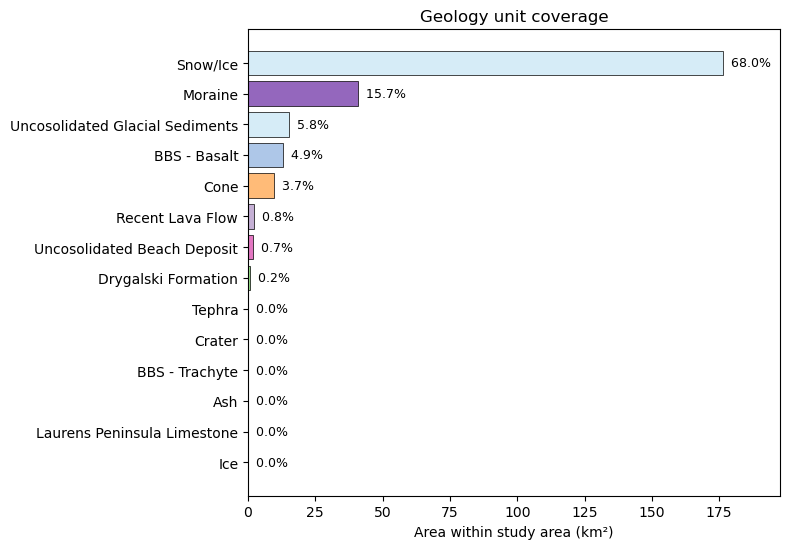

In [12]:
# ---- Area covered by each rock type ----
geo["area_km2"] = geo.geometry.area / 1e6
summary = (geo.groupby("Rock_Type")["area_km2"].sum()
              .sort_values(ascending=True)
              .to_frame("Area (km²)"))
summary["Share (%)"] = 100 * summary["Area (km²)"] / summary["Area (km²)"].sum()
display(summary.round(2).sort_values("Area (km²)", ascending=False))

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(summary))))
ax.barh(summary.index, summary["Area (km²)"],
        color=[colours[rt] for rt in summary.index], edgecolor="black", linewidth=0.5)
for y, (area, pct) in enumerate(zip(summary["Area (km²)"], summary["Share (%)"])):
    ax.text(area, y, f"  {pct:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Area within study area (km²)")
ax.set_title("Geology unit coverage")
ax.margins(x=0.12)
plt.tight_layout()
plt.savefig(outpath / "geology_area_by_type.png", dpi=200, bbox_inches="tight")
plt.show()